# Linear Algebra for Transformers

**The Vector Manipulation Toolkit**

Every operation inside a transformer — attention, projection, rotation —
is built from a small set of linear algebra operations on vectors. This
notebook builds that toolkit from scratch with 2D/3D examples you can
compute by hand, then connects each operation to where it appears in
Qwen3.6-35B-A3B.

We follow the same order the transformer does: rotate, then compare
(dot product), then transform (matrix × vector) up and down.

---

## 1. Vectors Are Just Lists of Numbers

A token embedding is a vector — 2048 numbers. Let's start with 2D so we
can draw it.

In [45]:
import numpy as np
import matplotlib.pyplot as plt

cat = np.array([0.8, 0.3])
dog = np.array([0.6, 0.7])

print(f"cat = {cat}")
print(f"dog = {dog}")
print(f"Each vector has {len(cat)} dimensions")

cat = [0.8 0.3]
dog = [0.6 0.7]
Each vector has 2 dimensions


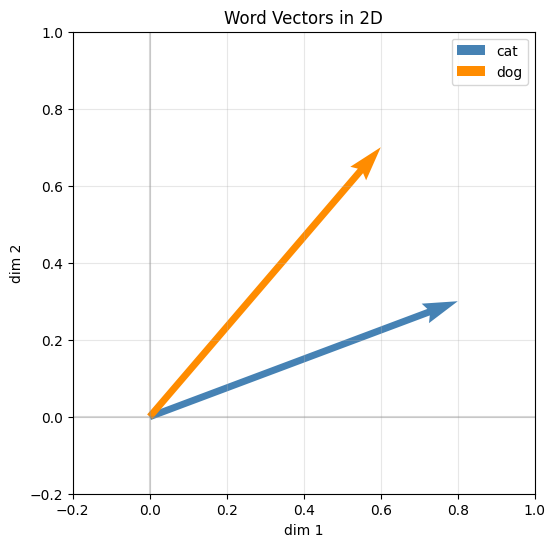

In [46]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.quiver(0, 0, cat[0], cat[1], angles='xy', scale_units='xy', scale=1,
          color='steelblue', width=0.015, label='cat')
ax.quiver(0, 0, dog[0], dog[1], angles='xy', scale_units='xy', scale=1,
          color='darkorange', width=0.015, label='dog')
ax.set_xlim(-0.2, 1.0); ax.set_ylim(-0.2, 1.0)
ax.set_xlabel('dim 1'); ax.set_ylabel('dim 2')
ax.axhline(y=0, color='gray', alpha=0.3); ax.axvline(x=0, color='gray', alpha=0.3)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend()
ax.set_title("Word Vectors in 2D")
plt.show()

In a real transformer, each token is a 2048-dimensional vector. The math we
do to these 2D vectors (rotate, dot product, matrix multiply) generalizes
directly to 2048D. Only the shapes of the matrices matter.

---

## 2. Rotation (Ep10 Recap)

Rotation is a special matrix multiply where the matrix is *orthogonal* —
it preserves the vector's length. The angle depends on the token's position.

**In transformers:** mRoPE rotates Q and K before computing attention
scores. Only 64 of 256 dims per head are rotated (25% partial factor).
This is how the model knows token order.

$$
R_\theta = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}
$$

In [47]:
theta = np.pi / 6  # 30 degrees
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

cat_rotated = R @ cat

print(f"Rotation matrix (θ = {np.degrees(theta):.0f}°):")
print(R)
print(f"\nOriginal:  {cat},  |cat| = {np.linalg.norm(cat):.4f}")
print(f"Rotated:   {cat_rotated},  |R·cat| = {np.linalg.norm(cat_rotated):.4f}")
print(f"\n✓ Rotation preserves the norm.")

Rotation matrix (θ = 30°):
[[ 0.8660254 -0.5      ]
 [ 0.5        0.8660254]]

Original:  [0.8 0.3],  |cat| = 0.8544
Rotated:   [0.54282032 0.65980762],  |R·cat| = 0.8544

✓ Rotation preserves the norm.


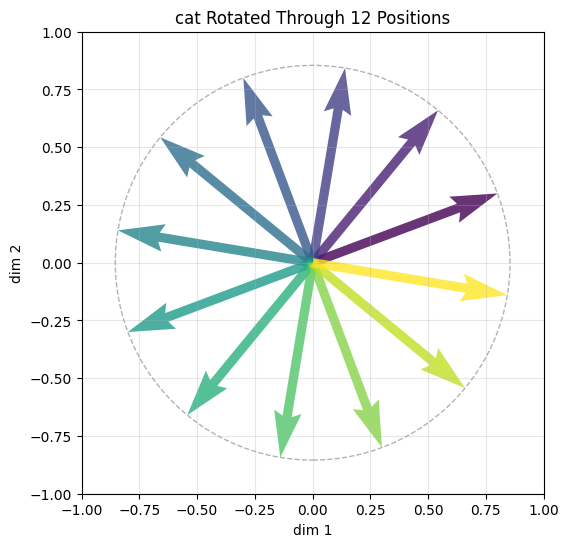

In [48]:
# cat rotated through 12 evenly-spaced positions
angles = np.linspace(0, 2*np.pi, 13)[:-1]
rotated = np.array([
    np.array([[np.cos(t), -np.sin(t)], [np.sin(t), np.cos(t)]]) @ cat
    for t in angles
])

fig, ax = plt.subplots(figsize=(6, 6))
ax.quiver(np.zeros(12), np.zeros(12),
          rotated[:, 0], rotated[:, 1],
          angles='xy', scale_units='xy', scale=1,
          color=plt.cm.viridis(np.linspace(0, 1, 12)),
          width=0.02, alpha=0.8)
circ = plt.Circle((0, 0), np.linalg.norm(cat), fill=False, linestyle='--', alpha=0.3)
ax.add_patch(circ)
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_xlabel('dim 1'); ax.set_ylabel('dim 2')
ax.set_title("cat Rotated Through 12 Positions")
plt.show()

---

## 3. The Dot Product: How Similar Are Two Vectors?

The dot product multiplies corresponding elements and sums them:

$$\mathbf{a} \cdot \mathbf{b} = a_1 b_1 + a_2 b_2 + \cdots = \sum_{i} a_i b_i$$

Geometrically: $\mathbf{a} \cdot \mathbf{b} = \|\mathbf{a}\| \|\mathbf{b}\| \cos(\theta)$

**In transformers:** the attention score between two tokens IS a dot product:
$\text{score}_{i,j} = Q_i \cdot K_j$

In [49]:
dot = np.dot(cat, dog)
by_hand = cat[0]*dog[0] + cat[1]*dog[1]

print(f"cat · dog  = {cat[0]}×{dog[0]} + {cat[1]}×{dog[1]} = {by_hand:.4f}")
print(f"np.dot    = {dot:.4f}")

# Compare with a random vector
random_vec = np.array([-0.2, 0.9])
print(f"\ncat · random_vec = {np.dot(cat, random_vec):.4f}")
print(f"dog · random_vec = {np.dot(dog, random_vec):.4f}")

# A vector dotted with itself gives its squared length
print(f"\ncat · cat    = {np.dot(cat, cat):.4f}  (= |cat|² = {np.linalg.norm(cat)**2:.4f})")
print(f"dog · dog    = {np.dot(dog, dog):.4f}  (= |dog|² = {np.linalg.norm(dog)**2:.4f})")
print(f"cat · (-cat) = {np.dot(cat, -cat):.4f}  (opposite direction → negative)")

cat · dog  = 0.8×0.6 + 0.3×0.7 = 0.6900
np.dot    = 0.6900

cat · random_vec = 0.1100
dog · random_vec = 0.5100

cat · cat    = 0.7300  (= |cat|² = 0.7300)
dog · dog    = 0.8500  (= |dog|² = 0.8500)
cat · (-cat) = -0.7300  (opposite direction → negative)


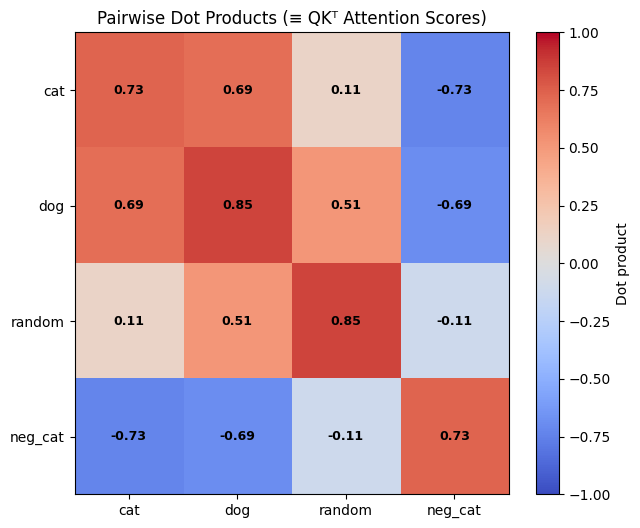

In [50]:
# Dot product heatmap — this IS the QK^T attention score matrix
words = {'cat': cat, 'dog': dog, 'random': random_vec, 'neg_cat': -cat}
names = list(words.keys())
n = len(names)

scores = np.zeros((n, n))
for i, (ni, vi) in enumerate(words.items()):
    for j, (nj, vj) in enumerate(words.items()):
        scores[i, j] = np.dot(vi, vj)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(scores, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(names)
ax.set_yticks(range(n)); ax.set_yticklabels(names)
ax.set_title("Pairwise Dot Products (≡ QKᵀ Attention Scores)")
plt.colorbar(im, ax=ax, label='Dot product')
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{scores[i,j]:.2f}', ha='center', va='center', fontsize=9, fontweight='bold')
plt.show()

This grid IS the $QK^T$ attention score matrix — just with 2D toy vectors
instead of 256D head vectors. Each cell is a dot product between two token
representations. Red = related, blue = unrelated.

**But there's a problem.** Notice that `dog·dog = 0.85` while `cat·cat = 0.73`.
Same operation (self-similarity), different results. Why?

---

## 4. The Problem: Length Distorts Similarity

`a·a = |a|²`. So `dog·dog` is larger simply because `dog` is a longer vector.

In a transformer, this means a token with a large-magnitude key vector would
dominate the softmax — not because it's semantically relevant, but purely
because its vector is longer. This would make attention unstable.

**The fix: Normalize vectors to unit length.** Then `a·b` depends only on
the angle between them (cosine similarity), not their lengths.

This is exactly why Qwen3.5 applies **QK Norm** — RMSNorm on Q and K before
attention. Each head's vectors are scaled to unit variance so the dot product
measures direction, not magnitude.

In [51]:
# Without normalization: different self-similarities
print("Before normalization:")
print(f"  cat·cat = {np.dot(cat, cat):.4f}")
print(f"  dog·dog = {np.dot(dog, dog):.4f}")
print(f"  cat·dog = {np.dot(cat, dog):.4f}")

# Normalize to unit length
cat_norm = cat / np.linalg.norm(cat)
dog_norm = dog / np.linalg.norm(dog)
rand_norm = random_vec / np.linalg.norm(random_vec)

print(f"\nAfter normalization (unit vectors):")
print(f"  cat_norm·cat_norm = {np.dot(cat_norm, cat_norm):.4f}  ← always 1.0!")
print(f"  dog_norm·dog_norm = {np.dot(dog_norm, dog_norm):.4f}  ← always 1.0!")
print(f"  cat_norm·dog_norm = {np.dot(cat_norm, dog_norm):.4f}  ← pure cosine similarity")

# The normalized dot product IS the cosine of the angle
cos_angle = np.dot(cat_norm, dog_norm)
angle = np.degrees(np.arccos(cos_angle))
print(f"\ncos(θ) = {cos_angle:.4f} → θ = {angle:.1f}°")
print(f"This measures ONLY direction, not vector length.")

Before normalization:
  cat·cat = 0.7300
  dog·dog = 0.8500
  cat·dog = 0.6900

After normalization (unit vectors):
  cat_norm·cat_norm = 1.0000  ← always 1.0!
  dog_norm·dog_norm = 1.0000  ← always 1.0!
  cat_norm·dog_norm = 0.8759  ← pure cosine similarity

cos(θ) = 0.8759 → θ = 28.8°
This measures ONLY direction, not vector length.


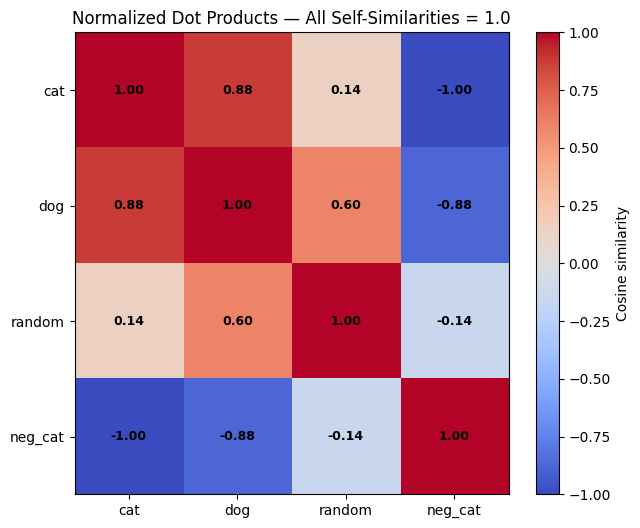

In [52]:
# Heatmap with normalized vectors — all self-similarities are now 1.0
norm_words = {'cat': cat_norm, 'dog': dog_norm, 'random': rand_norm, 'neg_cat': -cat_norm}
norm_names = list(norm_words.keys())
n = len(norm_names)

scores_norm = np.zeros((n, n))
for i, (ni, vi) in enumerate(norm_words.items()):
    for j, (nj, vj) in enumerate(norm_words.items()):
        scores_norm[i, j] = np.dot(vi, vj)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(scores_norm, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(norm_names)
ax.set_yticks(range(n)); ax.set_yticklabels(norm_names)
ax.set_title("Normalized Dot Products — All Self-Similarities = 1.0")
plt.colorbar(im, ax=ax, label='Cosine similarity')
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{scores_norm[i,j]:.2f}', ha='center', va='center', fontsize=9, fontweight='bold')
plt.show()

**QK Norm in Qwen3.5:** RMSNorm is applied to Q and K per head, making each
head's vectors have unit variance. This ensures attention scores depend on
semantic direction, not vector magnitude. V is deliberately NOT normalized —
the model can still control how much information a token carries through the
magnitude of V.

---

## 5. Matrix × Vector: Transforming One Vector Into Another

A matrix is a rectangular grid of learned numbers. Multiply by a vector to
get a new vector — possibly with a different number of dimensions.

$$\mathbf{y} = \mathbf{W}\mathbf{x} \quad\text{where}\quad y_i = \sum_{j} W_{ij}\, x_j$$

**In transformers:** Every projection (W_Q, W_K, W_V, W_O) is a matrix×vector
multiply. The hidden state h (2048D) is multiplied by learned weight matrices.

In [53]:
# A 2×3 matrix transforms a 3D vector into a 2D vector
W = np.array([[1.0, 0.5, -0.3],
              [0.2, 0.8,  0.4]])
x = np.array([0.8, 0.3, 0.5])  # 3D

y = W @ x  # matrix @ vector

print(f"W shape: {W.shape}  (output_dim × input_dim)")
print(f"x shape: {x.shape}  (input_dim,)")
print(f"y shape: {y.shape}  (output_dim,)")
print(f"\ny = W @ x = {y}")
print(f"\nStep by step:")
print(f"  y[0] = {W[0,0]}×{x[0]} + {W[0,1]}×{x[1]} + {W[0,2]}×{x[2]} = {y[0]:.2f}")
print(f"  y[1] = {W[1,0]}×{x[0]} + {W[1,1]}×{x[1]} + {W[1,2]}×{x[2]} = {y[1]:.2f}")

W shape: (2, 3)  (output_dim × input_dim)
x shape: (3,)  (input_dim,)
y shape: (2,)  (output_dim,)

y = W @ x = [0.8 0.6]

Step by step:
  y[0] = 1.0×0.8 + 0.5×0.3 + -0.3×0.5 = 0.80
  y[1] = 0.2×0.8 + 0.8×0.3 + 0.4×0.5 = 0.60


**The shape rule:** If `W` is `(m × n)` and `x` is `(n,)`, result is `(m,)`.
Inner dimensions must match. This determines every projection shape:

| Projection | W shape | h shape | Result shape |
|-----------|---------|---------|-------------|
| Q + gate | 8192 × 2048 | 2048, | 8192, |
| K | 512 × 2048 | 2048, | 512, |
| V | 512 × 2048 | 2048, | 512, |
| O | 2048 × 4096 | 4096, | 2048, |

---

## 6. Projecting Up: Going to a Higher Dimension

When W has **more rows than columns** (tall matrix), the output has MORE
dimensions than the input. The vector is "projected up."

We'll project our 2D cat vector into 3D so we can see it happen.

**In transformers:** The Q projection takes h (2048D) → Q (4096D). Same math,
just with a 8192×2048 matrix instead of 3×2.

In [54]:
# Project a 2D vector up to 3D
# Choose W_up so the result lifts to ~45° off the xy floor
W_up = np.array([[0.6, 0.1],
                 [0.1, 0.7],
                 [0.5, 0.5]])

v_3d = W_up @ cat

print(f"Input:  cat = {cat}  (2D, on the xy floor)")
print(f"Output: v_3d = {v_3d}  (3D, lifted ~43° off the floor)")
print(f"\nW_up shape: {W_up.shape} — tall matrix (3 rows > 2 cols)")
print(f"Result: {len(v_3d)}D > {len(cat)}D → projected UP")

Input:  cat = [0.8 0.3]  (2D, on the xy floor)
Output: v_3d = [0.51 0.29 0.55]  (3D, lifted ~43° off the floor)

W_up shape: (3, 2) — tall matrix (3 rows > 2 cols)
Result: 3D > 2D → projected UP


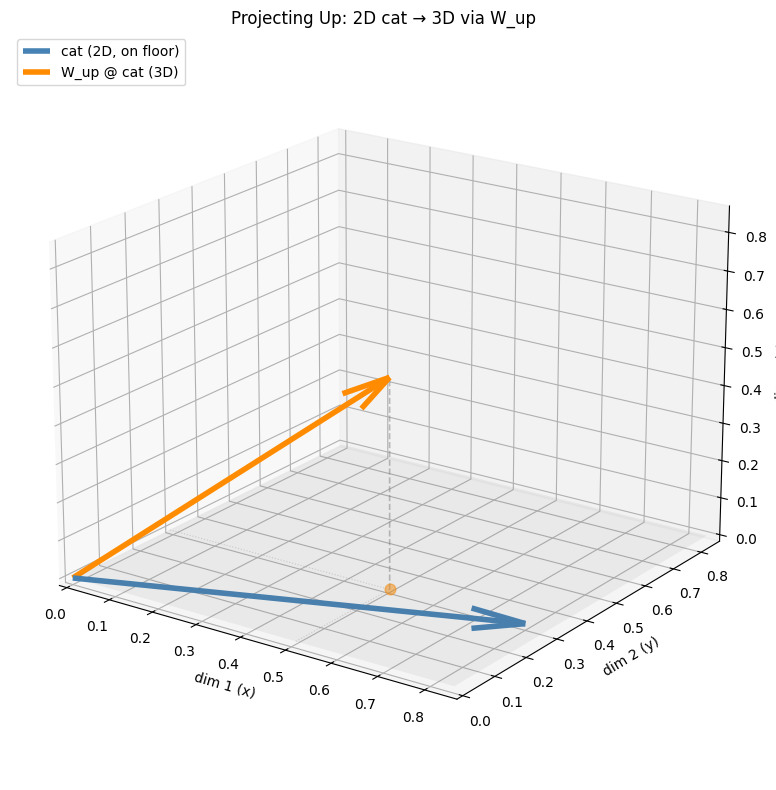

In [55]:
# 3D visualization: original cat on xy-floor, projected v_3d in 3D space
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# The xy-plane (z=0) — the "floor" where the original vector lives
xx, yy = np.meshgrid(np.linspace(0, 0.85, 4), np.linspace(0, 0.85, 4))
ax.plot_surface(xx, yy, np.zeros_like(xx), alpha=0.08, color='gray')

# Original cat vector on the floor (z=0)
ax.quiver(0, 0, 0, cat[0], cat[1], 0,
          color='steelblue', linewidth=4, arrow_length_ratio=0.12, label='cat (2D, on floor)')

# Projected vector in 3D — should stand out at ~43° from the floor
ax.quiver(0, 0, 0, v_3d[0], v_3d[1], v_3d[2],
          color='darkorange', linewidth=4, arrow_length_ratio=0.12, label='W_up @ cat (3D)')

# Dashed vertical drop line from the 3D tip to its shadow on the floor
ax.plot([v_3d[0], v_3d[0]], [v_3d[1], v_3d[1]], [0, v_3d[2]],
        '--', color='gray', alpha=0.5, linewidth=1.2)
# Dotted lines from shadow to axes
ax.plot([v_3d[0], v_3d[0]], [0, v_3d[1]], [0, 0],
        ':', color='gray', alpha=0.3, linewidth=0.8)
ax.plot([0, v_3d[0]], [v_3d[1], v_3d[1]], [0, 0],
        ':', color='gray', alpha=0.3, linewidth=0.8)

# Shadow dot on the floor
ax.scatter([v_3d[0]], [v_3d[1]], [0], color='darkorange', alpha=0.5, s=60)

# Tight limits: origin in corner, just beyond vector extents
ax.set_xlim(0, 0.85); ax.set_ylim(0, 0.85); ax.set_zlim(0, 0.85)
ax.set_xlabel('dim 1 (x)'); ax.set_ylabel('dim 2 (y)'); ax.set_zlabel('dim 3 (z)')
ax.set_title('Projecting Up: 2D cat → 3D via W_up')
ax.legend(loc='upper left')
ax.view_init(elev=20, azim=-55)
plt.tight_layout()
plt.show()

The orange vector has been **lifted off the floor** into a third dimension.
The original 2D information (x, y) is still there — you can see its shadow
on the floor — but now there's a new z-component adding expressive capacity.

This is what the Q projection does: it gives each token's representation
*more room* by projecting into a higher-dimensional space. In Qwen3.6,
the hidden state goes from 2048D to 8192D — that extra space is where
16 attention heads can work simultaneously.

---

## 7. Projecting Down: Squeezing Back to Fewer Dimensions

When W has **fewer rows than columns** (wide matrix), the output has FEWER
dimensions. The vector is "projected down" or compressed.

We'll project our 3D vector back down to 2D and see how much of the original
cat survives the round-trip.

**In transformers:** The output projection takes the concatenated head
outputs (4096D) back to the residual stream (2048D). 16 heads' worth
of information must be compressed — the model learns what to keep.

In [56]:
# Project the 3D vector back down to 2D
W_down = np.array([[0.4, 0.5, 0.2],
                   [0.3, 0.1, 0.6]])

v_2d_back = W_down @ v_3d

print(f"Input (3D):  {v_3d}")
print(f"Output (2D): {v_2d_back}")
print(f"Original:    {cat}")
print(f"\nW_down shape: {W_down.shape} — wide matrix (2 rows < 3 cols)")
print(f"\nChange:   |Δ| = {np.linalg.norm(v_2d_back - cat):.4f}")
print(f"Original: |cat| = {np.linalg.norm(cat):.4f}")
print(f"Output:   |out| = {np.linalg.norm(v_2d_back):.4f}")
print(f"\nOutput ≠ original — information was lost in compression.")
print(f"The model learns which information to preserve.")

Input (3D):  [0.51 0.29 0.55]
Output (2D): [0.459 0.512]
Original:    [0.8 0.3]

W_down shape: (2, 3) — wide matrix (2 rows < 3 cols)

Change:   |Δ| = 0.4015
Original: |cat| = 0.8544
Output:   |out| = 0.6876

Output ≠ original — information was lost in compression.
The model learns which information to preserve.


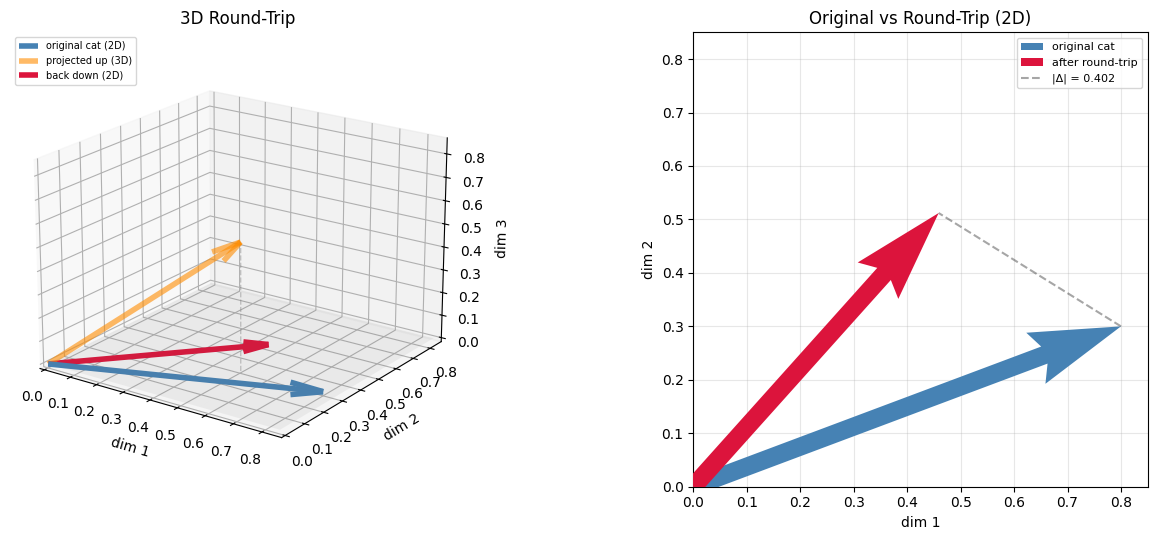

In [57]:
# Side-by-side: 3D round-trip and 2D before/after comparison
fig = plt.figure(figsize=(14, 5.5))

# Left: 3D view showing the full round trip
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
xx, yy = np.meshgrid(np.linspace(0, 0.85, 4), np.linspace(0, 0.85, 4))
ax1.plot_surface(xx, yy, np.zeros_like(xx), alpha=0.08, color='gray')
# Original on floor
ax1.quiver(0, 0, 0, cat[0], cat[1], 0,
           color='steelblue', linewidth=4, arrow_length_ratio=0.12, label='original cat (2D)')
# Up to 3D
ax1.quiver(0, 0, 0, v_3d[0], v_3d[1], v_3d[2],
           color='darkorange', linewidth=4, arrow_length_ratio=0.12, alpha=0.6, label='projected up (3D)')
# Back down to 2D
ax1.quiver(0, 0, 0, v_2d_back[0], v_2d_back[1], 0,
           color='crimson', linewidth=4, arrow_length_ratio=0.12, label='back down (2D)')
# Drop line
ax1.plot([v_3d[0], v_3d[0]], [v_3d[1], v_3d[1]], [0, v_3d[2]],
         '--', color='gray', alpha=0.4, linewidth=1)
ax1.set_xlim(0, 0.85); ax1.set_ylim(0, 0.85); ax1.set_zlim(0, 0.85)
ax1.set_xlabel('dim 1'); ax1.set_ylabel('dim 2'); ax1.set_zlabel('dim 3')
ax1.set_title('3D Round-Trip')
ax1.legend(loc='upper left', fontsize=7)
ax1.view_init(elev=20, azim=-55)

# Right: 2D comparison of original vs result
ax2 = fig.add_subplot(1, 2, 2)
ax2.quiver(0, 0, cat[0], cat[1], angles='xy', scale_units='xy', scale=1,
          color='steelblue', width=0.04, label='original cat', zorder=3)
ax2.quiver(0, 0, v_2d_back[0], v_2d_back[1], angles='xy', scale_units='xy', scale=1,
          color='crimson', width=0.04, label='after round-trip', zorder=3)
# Dashed line connecting tips to show the compression error
ax2.plot([cat[0], v_2d_back[0]], [cat[1], v_2d_back[1]],
         'k--', alpha=0.35, linewidth=1.5, label=f'|Δ| = {np.linalg.norm(v_2d_back - cat):.3f}')
ax2.set_xlim(0, 0.85); ax2.set_ylim(0, 0.85)
ax2.set_xlabel('dim 1'); ax2.set_ylabel('dim 2')
ax2.set_aspect('equal'); ax2.grid(True, alpha=0.3)
ax2.set_title('Original vs Round-Trip (2D)')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

---

## 8. Putting It All Together

Every operation in the attention mechanism is one we just learned:

In [58]:
operations = [
    ("2. Rotation",        "mRoPE(Q), mRoPE(K) — encode position", "R_θ @ q"),
    ("3. Dot product",     "Q·K — attention score between tokens", "q^T k / √d"),
    ("4. Normalize",       "QK Norm — remove length bias", "RMSNorm(q), RMSNorm(k)"),
    ("6. Project UP",      "h → Q (2048→4096) — expand for 16 heads", "W_Q @ h"),
    ("7. Project DOWN",    "Concat heads → output (4096→2048)", "W_O @ concat"),
    ("5. Matrix×Vec (same)","h → K, V (2048→512) — lean GQA", "W_K @ h, W_V @ h"),
]

print(f"{'Section':<22} {'Transformer Role':<42} {'Notation':<22}")
print("-" * 88)
for sec, role, notation in operations:
    print(f"{sec:<22} {role:<42} {notation:<22}")

Section                Transformer Role                           Notation              
----------------------------------------------------------------------------------------
2. Rotation            mRoPE(Q), mRoPE(K) — encode position       R_θ @ q               
3. Dot product         Q·K — attention score between tokens       q^T k / √d            
4. Normalize           QK Norm — remove length bias               RMSNorm(q), RMSNorm(k)
6. Project UP          h → Q (2048→4096) — expand for 16 heads    W_Q @ h               
7. Project DOWN        Concat heads → output (4096→2048)          W_O @ concat          
5. Matrix×Vec (same)   h → K, V (2048→512) — lean GQA             W_K @ h, W_V @ h      


---

## 9. Bridge to Reality

Open `projections.html` to see the same operations with Qwen3.6's actual
shapes:

| Operation | Toy | Real (Qwen3.6) |
|-----------|-----|----------------|
| Rotation (R_θ) | 2D × 2D | 64 of 256 dims per head |
| Q projection (up) | 2D → 5D | 2048D → 8192D |
| K projection (same-d) | 3D → 2D | 2048D → 512D |
| O projection (down) | 5D → 2D | 4096D → 2048D |

The math is identical. Only the numbers are bigger.

**In Ep12:** We load Qwen3.6-35B-A3B and watch these operations happen on
real vectors — extracting actual Q, K, V projections and reading the
attention weights they produce.